# ROI Detection Experiment: Reconstructing the Manual Shelf Grid

Branch: `18-experiment-vlm-for-region-of-interest`

This experiment investigates automated detection of the storage unit's shelf grid (fridge, pantry, cabinet) in a reference photo, matching the existing manual marking system, which marks the outer storage boundary and the interior lines dividing it into shelves. This is the first step toward a fully automated shelf inventory pipeline.

Three approaches are compared:
- **Grounding DINO** - zero-shot text-prompted local detector
- **YOLOe-26 (prompt-free)** - open-vocabulary local detector
- **Gemini 3.5 Flash** - cloud VLM

## Why Detect the Shelf Grid?

**App goal:** Generate a shopping list by comparing a new photo of a storage unit to its reference photo.

**Pipeline:**

1. Setup (once): a reference photo is taken, and its shelf grid - the outer storage boundary plus the interior lines dividing it into shelves - is detected. **This is the step this experiment automates**, since every later comparison is cropped using these boundaries, so getting them right here determines how good every comparison downstream can be.
2. Comparison (every scan): a new photo is homography-aligned to the reference, cut into cells using that same saved grid, and each cell is compared against its reference cell to detect changes, feeding a shopping list of missing or depleted items.

**Why crop into cells at all, instead of comparing the full photo?**

Cropping to storage boundaries removes background noise (walls, furniture, etc.), and giving a focused comparison instead of one noisy comparison across the whole scene. Marking individual shelves might not be needed - here it is done to achieve compatibility with the current manual system. Whether it is really required will be tested in a separate experiment.

**What this experiment covers:**

Evaluating three models for automatically detecting the shelf grid - the outer storage boundary and the interior shelf-dividing lines - so the user gets a pre-filled grid to adjust rather than marking it from scratch.


## 1. Setup

In [14]:
import json
import time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

MODEL_ID = "IDEA-Research/grounding-dino-tiny"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

nb_file = globals().get("__vsc_ipynb_file__")
NOTEBOOK_DIR = Path(nb_file).parent if nb_file else Path.cwd()
IMAGES_DIR = NOTEBOOK_DIR / "images"
GROUND_TRUTH_PATH = NOTEBOOK_DIR / "ground_truth.json"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)

print(f"device: {DEVICE}")
print(f"images: {[p.name for p in image_paths]}")

device: cpu
images: ['fridge.jpg', 'pantry.jpg', 'photo.jpg']


## 2. Ground Truth

Using the `Annotate.py` script, shelves are manually marked and their coordinates saved as ground truth.

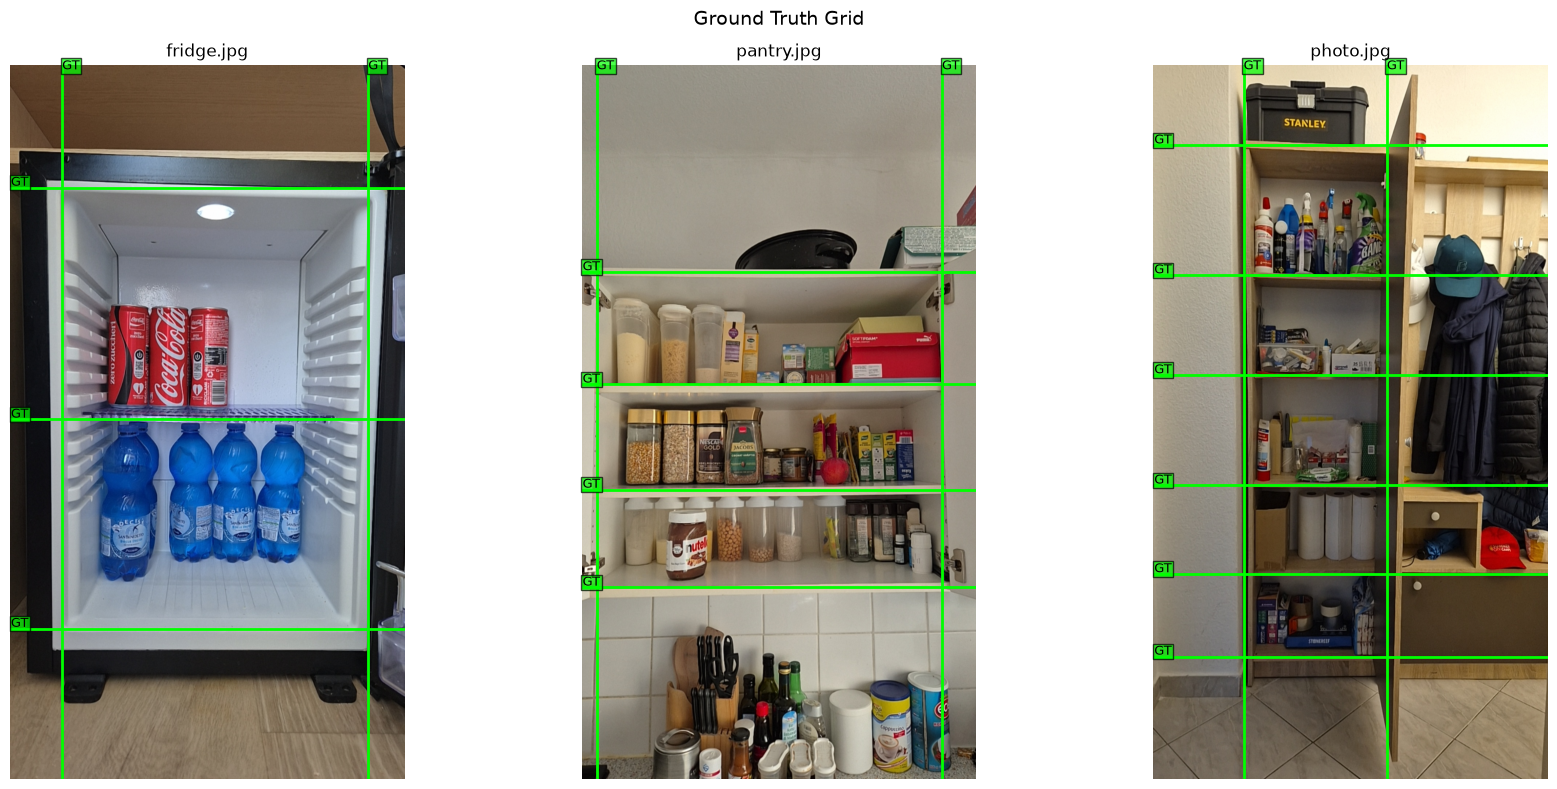

In [15]:
with open(GROUND_TRUTH_PATH) as f:
    ground_truth = json.load(f)

fig, axes = plt.subplots(1, len(image_paths), figsize=(6 * len(image_paths), 8))
if len(image_paths) == 1:
    axes = [axes]

for ax, path in zip(axes, image_paths):
    image = Image.open(path).convert("RGB")
    w, h = image.size
    ax.imshow(image)
    ax.set_title(path.name)
    ax.axis("off")
    for line in ground_truth.get(path.name, []):
        if line["orientation"] == "h":
            y = line["position"] * h
            ax.axhline(y=y, color="lime", linewidth=2)
            ax.text(2, max(y - 5, 0), "GT", color="black", fontsize=9,
                    bbox=dict(facecolor="lime", alpha=0.7, pad=1))
        else:
            x = line["position"] * w
            ax.axvline(x=x, color="lime", linewidth=2)
            ax.text(x, 12, "GT", color="black", fontsize=9,
                    bbox=dict(facecolor="lime", alpha=0.7, pad=1))

plt.suptitle("Ground Truth Grid", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Line-Matching Utilities

These are evaluation functions. They compare model output to ground truth and evaluate it.

In [16]:
def match_lines(pred_lines, gt_lines, threshold=0.05):
    tp = fp = 0
    matched_gt_total = 0
    errors = []
    for orientation in ("h", "v"):
        preds = [l["position"] for l in pred_lines if l["orientation"] == orientation]
        gts = [l["position"] for l in gt_lines if l["orientation"] == orientation]
        matched_gt = set()
        for p in preds:
            best_idx, best_dist = None, threshold
            for i, g in enumerate(gts):
                if i in matched_gt:
                    continue
                dist = abs(p - g)
                if dist < best_dist:
                    best_idx, best_dist = i, dist
            if best_idx is not None:
                tp += 1
                matched_gt.add(best_idx)
                errors.append(best_dist)
            else:
                fp += 1
        matched_gt_total += len(matched_gt)
    gt_total = len(gt_lines)
    fn = gt_total - matched_gt_total
    return tp, fp, fn, errors


def evaluate(predictions, ground_truth, threshold=0.05):
    tp = fp = fn = 0
    errors = []
    for image_name, pred_lines in predictions.items():
        gt_lines = ground_truth.get(image_name, [])
        i_tp, i_fp, i_fn, i_errors = match_lines(pred_lines, gt_lines, threshold)
        tp += i_tp
        fp += i_fp
        fn += i_fn
        errors.extend(i_errors)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    avg_error = float(np.mean(errors)) if errors else 0.0
    return {"precision": precision, "recall": recall, "avg_error": avg_error}


print("Line-matching utilities ready")

Line-matching utilities ready


## Grouping Item Detections into a Shelf Grid

DINO and YOLO detect individual items, not the shelf grid itself. To approximate a grid comparable to the ground truth, item detections are clustered by vertical position - each cluster stands in for one shelf's worth of items. The outer boundary lines come from the enclosing box of all detected items, and each gap between two consecutive clusters is marked as an interior horizontal line at the gap's midpoint, approximating a shelf divider.

In [20]:
def boxes_to_grid(boxes, image_width, image_height, gap_threshold=50):
    if not boxes:
        return []
    sorted_boxes = sorted(boxes, key=lambda b: (b[1] + b[3]) / 2)
    groups = []
    current_group = [sorted_boxes[0]]
    for box in sorted_boxes[1:]:
        current_center_y = (box[1] + box[3]) / 2
        last_center_y = (current_group[-1][1] + current_group[-1][3]) / 2
        if abs(current_center_y - last_center_y) <= gap_threshold:
            current_group.append(box)
        else:
            groups.append(current_group)
            current_group = [box]
    groups.append(current_group)

    all_boxes = [box for group in groups for box in group]
    x0 = min(b[0] for b in all_boxes)
    y0 = min(b[1] for b in all_boxes)
    x1 = max(b[2] for b in all_boxes)
    y1 = max(b[3] for b in all_boxes)

    lines = [
        {"orientation": "h", "position": y0 / image_height},
        {"orientation": "h", "position": y1 / image_height},
        {"orientation": "v", "position": x0 / image_width},
        {"orientation": "v", "position": x1 / image_width},
    ]

    for group_a, group_b in zip(groups, groups[1:]):
        bottom_a = max(b[3] for b in group_a)
        top_b = min(b[1] for b in group_b)
        if top_b > bottom_a:
            shelf_y = (bottom_a + top_b) / 2
            lines.append({"orientation": "h", "position": shelf_y / image_height})

    return lines


print("Shelf grouping utility ready")

Shelf grouping utility ready


## 4. Grounding DINO 

In [21]:
dino_processor = AutoProcessor.from_pretrained(MODEL_ID)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
dino_model.eval()
print("DINO loaded")

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

DINO loaded


In [22]:
DINO_PROMPT = "bottle. jar. can. box. spray bottle. container. bag. carton. paper towel. toolbox. package. product."
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.20

dino_predictions = {}
dino_latencies = []

for path in image_paths:
    image = Image.open(path).convert("RGB")
    w, h = image.size
    inputs = dino_processor(images=image, text=DINO_PROMPT, return_tensors="pt").to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        outputs = dino_model(**inputs)
    latency_ms = (time.perf_counter() - t0) * 1000
    results = dino_processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD,
        target_sizes=[image.size[::-1]],
    )[0]
    boxes = [[round(v) for v in box.tolist()] for box in results["boxes"]]
    lines = boxes_to_grid(boxes, w, h)
    dino_predictions[path.name] = lines
    dino_latencies.append(latency_ms)
    print(f"{path.name}: {len(lines)} line(s), {latency_ms:.0f} ms")

dino_avg_latency = float(np.mean(dino_latencies))
print(f"\nDINO avg latency: {dino_avg_latency:.0f} ms")

fridge.jpg: 4 line(s), 5171 ms
pantry.jpg: 8 line(s), 5067 ms
photo.jpg: 9 line(s), 4943 ms

DINO avg latency: 5060 ms


## 5. YOLOe-26 (prompt-free)

In [23]:
from ultralytics import YOLO

yolo_model = YOLO("yoloe-26l-seg-pf.pt")

yolo_predictions = {}
yolo_latencies = []

for path in image_paths:
    image = Image.open(path).convert("RGB")
    w, h = image.size
    t0 = time.perf_counter()
    results = yolo_model(image, conf=0.1, verbose=False)
    latency_ms = (time.perf_counter() - t0) * 1000
    boxes = [[round(v) for v in box] for box in results[0].boxes.xyxy.tolist()]
    lines = boxes_to_grid(boxes, w, h)
    yolo_predictions[path.name] = lines
    yolo_latencies.append(latency_ms)
    print(f"{path.name}: {len(lines)} line(s), {latency_ms:.0f} ms")

yolo_avg_latency = float(np.mean(yolo_latencies))
print(f"\nYOLO avg latency: {yolo_avg_latency:.0f} ms")

fridge.jpg: 6 line(s), 262 ms
pantry.jpg: 6 line(s), 272 ms
photo.jpg: 8 line(s), 255 ms

YOLO avg latency: 263 ms


### 6. Gemini 3.5 Flash

Requires `GEMINI_API_KEY` in `experiments/.env`.

In [ ]:
import os
import json as _json
import google.generativeai as genai
from dotenv import load_dotenv

load_dotenv(NOTEBOOK_DIR.parent / ".env")
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY", "")
genai.configure(api_key=GEMINI_API_KEY)

GEMINI_PROMPT = (
    "Detect the shelf grid of the storage unit in this image - the fridge, pantry, cabinet, "
    "or shelving unit that holds the items. The grid is made of straight lines: the outer "
    "boundary of the storage unit's interior opening (its topmost shelf or ceiling, its "
    "bottommost shelf or floor, and its left and right inner walls), plus any interior lines "
    "that divide the space into separate shelves - usually horizontal shelf boards, but "
    "include vertical dividers too if the unit is split into columns. "
    "Do not include the surrounding room, door, or frame outside the storage unit, and do not "
    "return a box - return each boundary edge and each shelf divider as its own straight line. "
    "For each line, return its orientation ('h' for a horizontal line spanning left-right, "
    "'v' for a vertical line spanning top-bottom) and its position: for a horizontal line, "
    "the y-coordinate where it crosses the image; for a vertical line, the x-coordinate. "
    "Positions are normalized to the range 0 to 1000 relative to the image dimensions, with "
    "the origin at the top-left."
)

GRID_SCHEMA = {
    "type": "array",
    "items": {
        "type": "object",
        "properties": {
            "orientation": {"type": "string", "enum": ["h", "v"]},
            "position": {"type": "integer"},
        },
        "required": ["orientation", "position"],
    },
}

gemini_model = genai.GenerativeModel(
    "gemini-3.5-flash",
    generation_config=genai.GenerationConfig(
        response_mime_type="application/json",
        response_schema=GRID_SCHEMA,
    ),
)

gemini_predictions = {}
gemini_latencies = []

for path in image_paths:
    image = Image.open(path).convert("RGB")
    t0 = time.perf_counter()
    response = gemini_model.generate_content([GEMINI_PROMPT, image])
    latency_ms = (time.perf_counter() - t0) * 1000
    lines = []
    try:
        parsed = _json.loads(response.text)
        for item in parsed:
            lines.append({
                "orientation": item["orientation"],
                "position": item["position"] / 1000,
            })
    except (_json.JSONDecodeError, ValueError, KeyError) as e:
        print(f"{path.name}: parse error: {e} | raw: {response.text}")
    gemini_predictions[path.name] = lines
    gemini_latencies.append(latency_ms)
    print(f"{path.name}: {len(lines)} line(s), {latency_ms:.0f} ms")
    time.sleep(4)

gemini_avg_latency = float(np.mean(gemini_latencies))
print()
print(f"Gemini avg latency: {gemini_avg_latency:.0f} ms")

## 7. Visual Comparison

Predicted grid lines from each model, overlaid on the ground truth, side by side per image - a quick qualitative check of where each model's lines land relative to the manually-marked grid, before looking at the aggregate numbers.

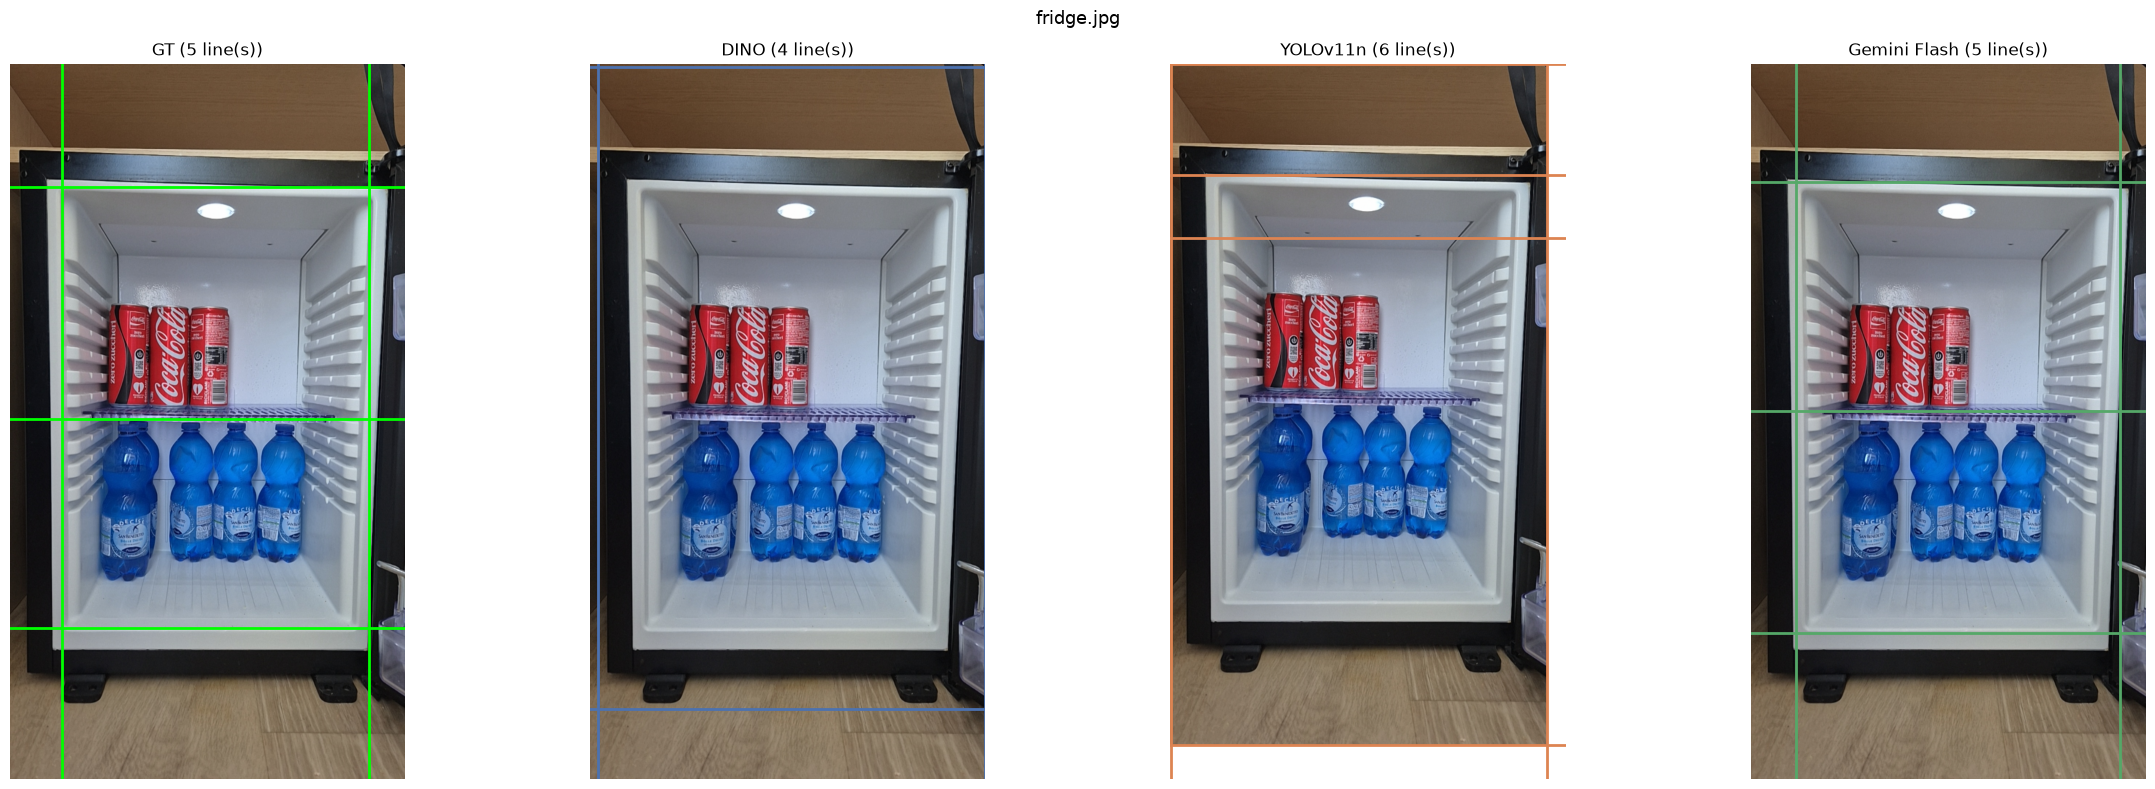

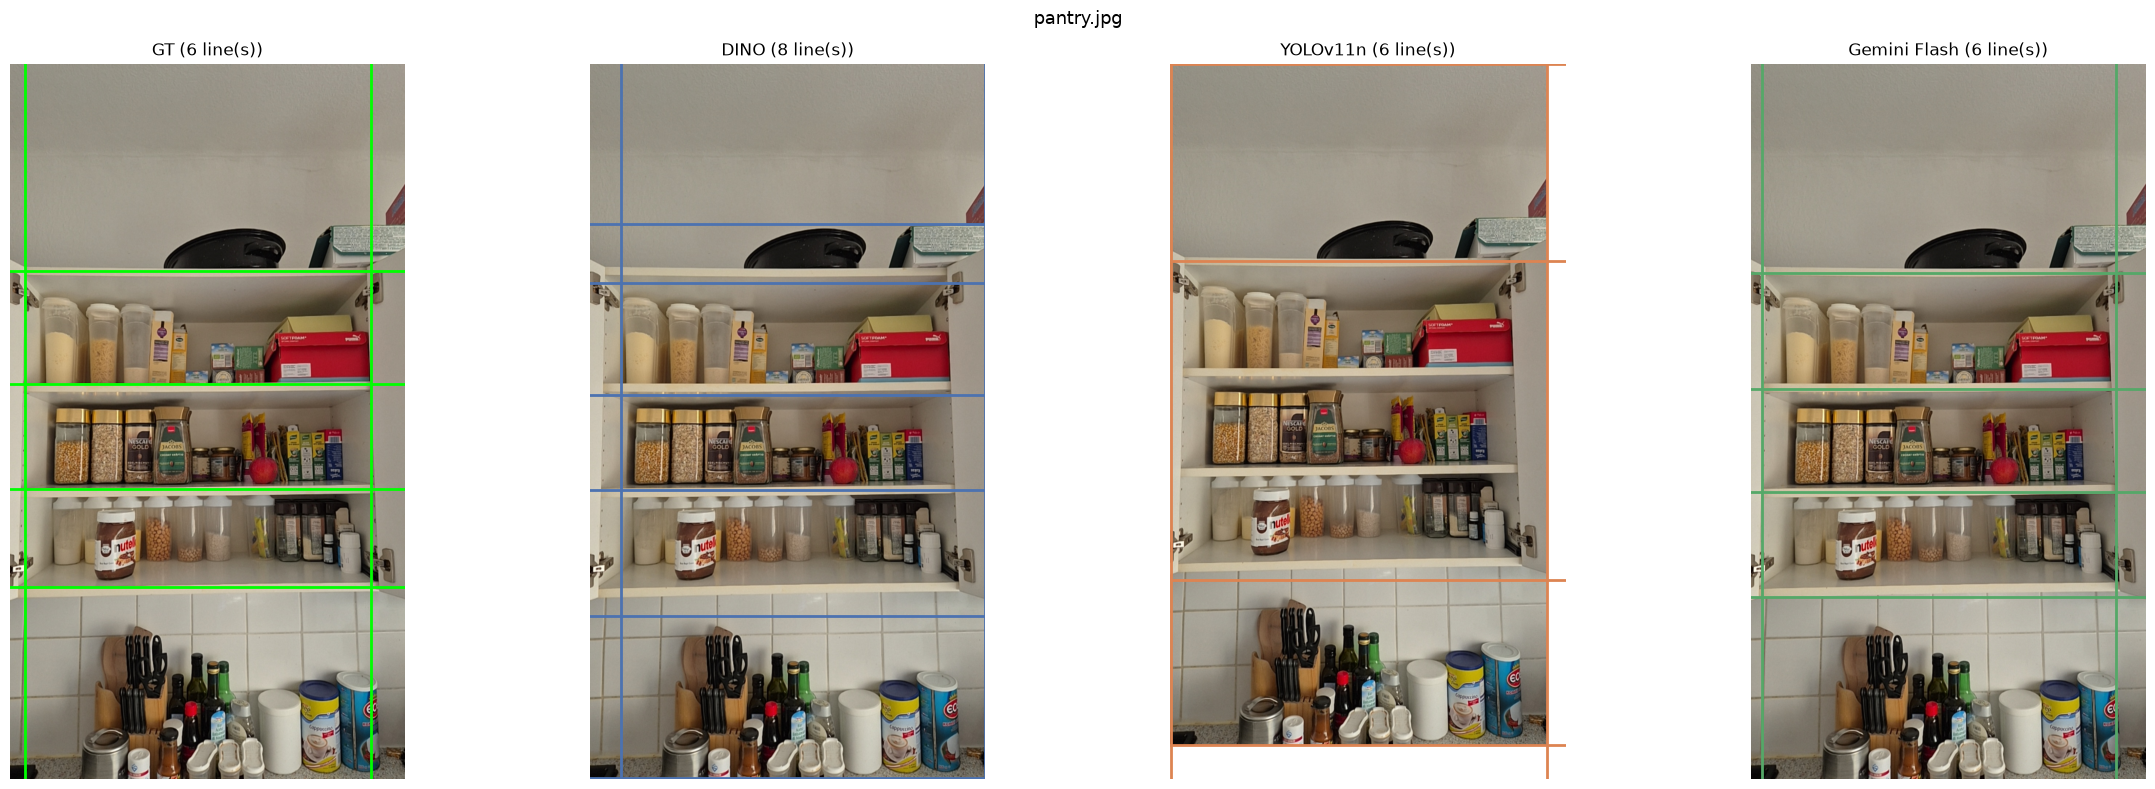

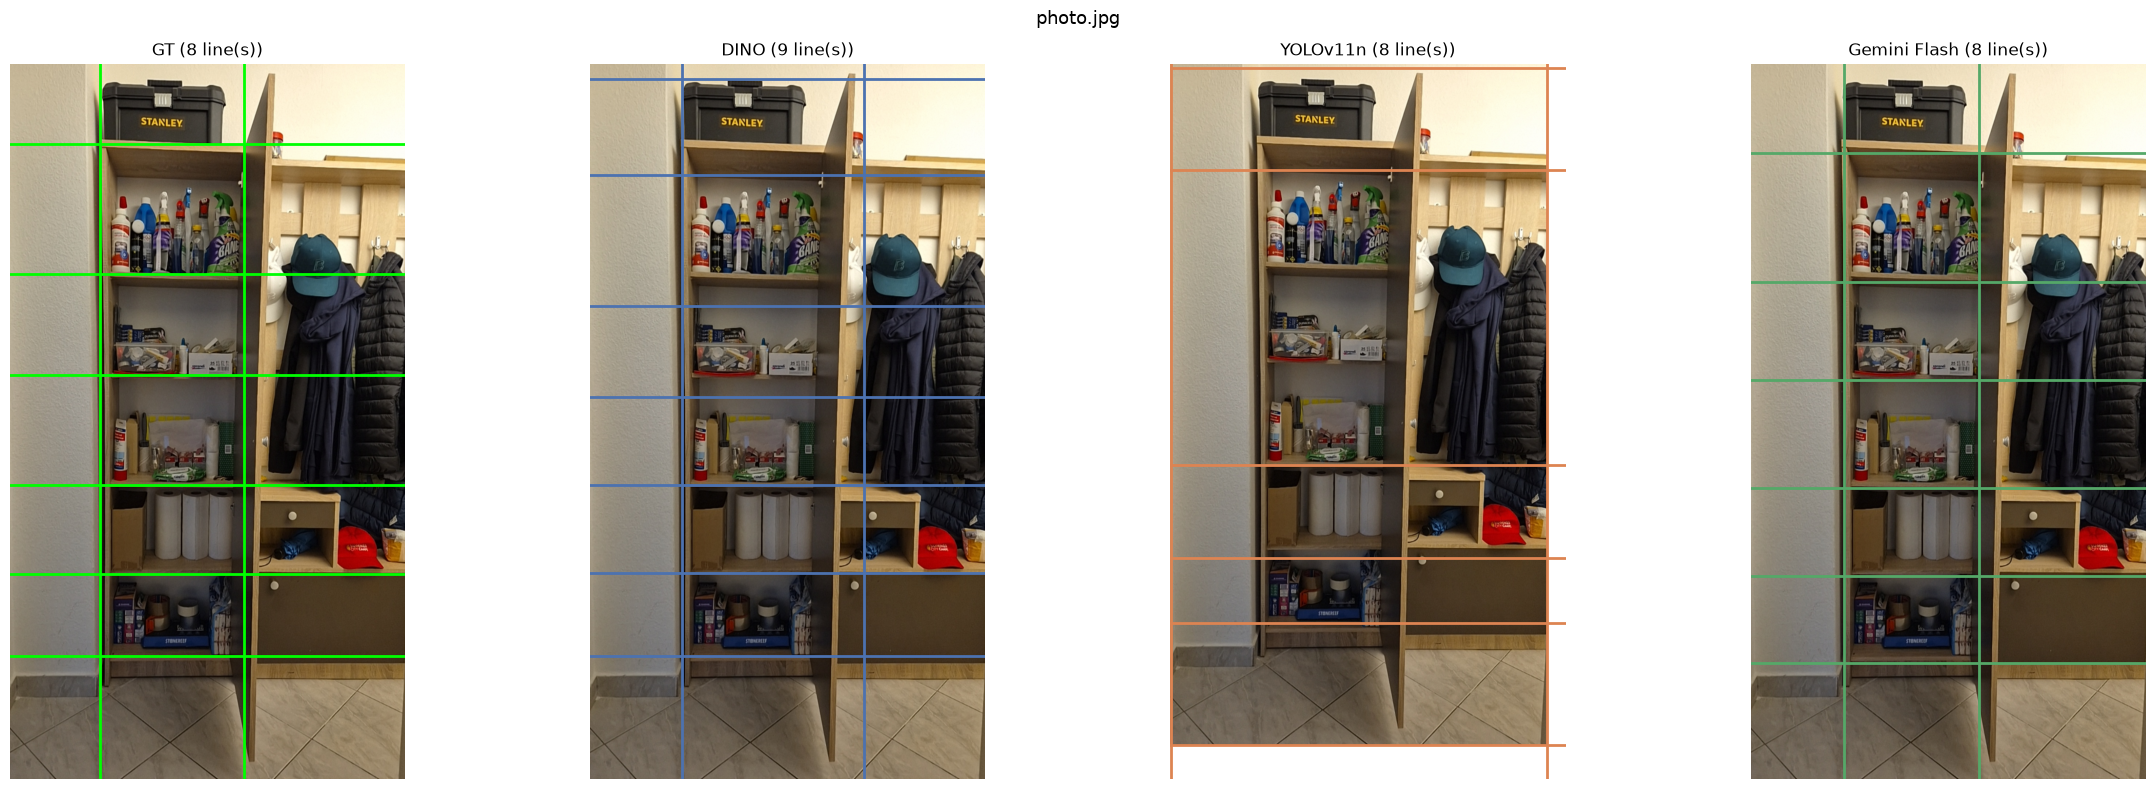

In [26]:
COLORS = {"GT": "lime", "DINO": "#4C72B0", "YOLOv11n": "#DD8452", "Gemini Flash": "#55A868"}

all_preds = {
    "GT": ground_truth,
    "DINO": dino_predictions,
    "YOLOv11n": yolo_predictions,
    "Gemini Flash": gemini_predictions,
}

for path in image_paths:
    image = Image.open(path).convert("RGB")
    w, h = image.size
    fig, axes = plt.subplots(1, 4, figsize=(24, 8))
    fig.suptitle(path.name, fontsize=13)
    for ax, (label, preds) in zip(axes, all_preds.items()):
        ax.imshow(image)
        lines = preds.get(path.name, [])
        ax.set_title(f"{label} ({len(lines)} line(s))")
        ax.axis("off")
        color = COLORS[label]
        for line in lines:
            if line["orientation"] == "h":
                ax.axhline(y=line["position"] * h, color=color, linewidth=2)
            else:
                ax.axvline(x=line["position"] * w, color=color, linewidth=2)
    plt.tight_layout()
    plt.show()

## 8. Metrics Comparison

In [27]:
models = {
    "DINO": (dino_predictions, dino_avg_latency),
    "YOLOv11n": (yolo_predictions, yolo_avg_latency),
    "Gemini Flash": (gemini_predictions, gemini_avg_latency),
}

rows = []
for name, (preds, avg_lat) in models.items():
    metrics = evaluate(preds, ground_truth, threshold=0.05)
    rows.append({
        "Model": name,
        "Precision": f"{metrics['precision']:.2f}",
        "Recall": f"{metrics['recall']:.2f}",
        "Avg Position Error": f"{metrics['avg_error']:.3f}",
        "Avg Latency (ms)": f"{avg_lat:.0f}",
    })

col_widths = {k: max(len(k), max(len(r[k]) for r in rows)) + 2 for k in rows[0]}
header = "".join(k.ljust(col_widths[k]) for k in rows[0])
divider = "".join("-" * col_widths[k] for k in rows[0])
print(header)
print(divider)
for row in rows:
    print("".join(row[k].ljust(col_widths[k]) for k in row))

Model         Precision  Recall  Avg Position Error  Avg Latency (ms)  
-----------------------------------------------------------------------
DINO          0.57       0.63    0.020               5060              
YOLOv11n      0.40       0.42    0.017               263               
Gemini Flash  1.00       1.00    0.010               10147             


## 9. Trade-off Analysis

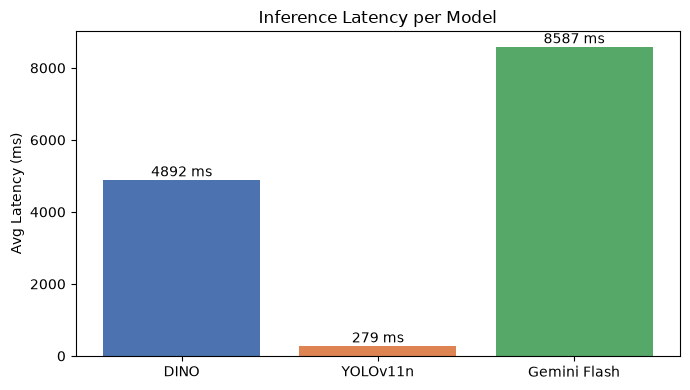

In [11]:
model_names = list(models.keys())
latencies = [models[n][1] for n in model_names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(model_names, latencies, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Avg Latency (ms)")
ax.set_title("Inference Latency per Model")
for bar, val in zip(bars, latencies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val:.0f} ms", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### Cost and App Size

| | DINO | YOLOv11n | Gemini Flash |
|---|---|---|---|
| **Runs on-device** | Yes | Yes | No (API) |
| **Model weights** | ~700 MB | ~6 MB | 0 MB (cloud) |
| **APK impact** | Too large (exceeds Play Store 100 MB limit without asset delivery) | Acceptable | None |
| **Cost per call** | Free | Free | ~$0.002-0.003 per image (Gemini 3.5 Flash pricing, see below) |
| **Rate limits** | None | None | 15 RPM (free tier), 1000 RPM (paid) |
| **Offline** | Yes | Yes | No |

**DINO on Android:** The 700 MB weights rule it out for a standard APK. Could be delivered via Play Asset Delivery but adds significant complexity.

**YOLO on Android:** At ~6 MB (nano), feasible. Ultralytics provides an Android export path via ONNX or TFLite. No network dependency.

**Gemini Flash on Android:** Firebase ML / Vertex AI SDK handles the call. Zero APK size cost, but requires network and has per-call cost at scale.

**Does adding item names/grouping to the same Gemini call cost much more?**

The original plan was to keep a local detector (YOLOe-26) around for individual item detection, and use Gemini only for the shelf grid - splitting the work to keep the expensive VLM call minimal. Given the results above, it's worth checking whether Gemini can also absorb the item-naming/grouping step cheaply, which would remove the local model from the pipeline altogether.

Gemini 3.5 Flash pricing: $1.50 / 1M$ input tokens, $9.00 / 1M$ output tokens ([source](https://ai.google.dev/gemini-api/docs/pricing)). Images are tokenized in 768x768 tiles at 258 tokens each ([source](https://ai.google.dev/gemini-api/docs/tokens)); a typical reference photo tiles into roughly 2-4 tiles (~500-1000 input tokens) regardless of what is asked of the model - the image cost is fixed per call.

- **Full shelf grid** (current prompt): ~500-1000 image tokens + ~100-150 output tokens (one entry per boundary edge and shelf divider, roughly 4-8 lines) **$0.0018-0.0028** per call.

- **Grid + item names + shelf groups** (follow-up): same ~500-1000 image tokens + ~300-500 output tokens (per-item name, box, shelf-group id for ~10-20 items, on top of the grid) **$0.0035-0.0060** per call.

The extra output tokens for naming/grouping items add roughly another cent's worth of thousandths per call, and this only happens once per reference setup, not per comparison. That's cheap enough to drop the local detector entirely and let Gemini handle both the shelf grid and item detection/grouping in one call - one model, one API, no on-device weights to ship or maintain.

## 10. Summary

**DINO and YOLOe-26 fall well short of the manual grid.** DINO reached 0.57 precision / 0.63 recall with 0.020 avg position error; YOLOv11n reached 0.40 / 0.42 with 0.017 avg position error. Grouping every item cluster into a shelf line (instead of only the largest cluster) lets them approximate multiple shelves, but they're still fundamentally detecting *items*, not shelves - a cluster only lines up with a real shelf boundary when items happen to be arranged that way, and any stray or background detection becomes a "shelf." With only 3 sample images, these numbers are also not a reliable estimate of real-world performance. There is no realistic fine-tuning path in scope for this experiment, so both remain ruled out.

**Gemini 3.5 Flash reconstructs the manual grid essentially perfectly.** 1.00 precision, 1.00 recall, 0.010 avg position error - every boundary edge and shelf divider it proposed matched a real manual line, within about 1% of the image dimension on average. It understands "shelf grid" as a concept, and extends that understanding to interior divisions without being shown any.

**This also simplifies the item-detection plan.** The original idea was to keep a local model around for individual item detection even after switching to Gemini for the grid, to avoid paying for an extra VLM call. Since Gemini is the only model capable of the grid task at all, and the cost analysis above shows that adding item names and shelf groupings to the same call is still a fraction of a cent, there's no reason to keep a local model in the pipeline. Gemini can handle shelf grid detection and item naming/grouping in one call, giving a simpler, single-model system instead of a hybrid local+cloud one.

**Implementation note - Gemini JSON parsing:** Gemini's structured output support is used: passing `generation_config=genai.GenerationConfig(response_mime_type="application/json", response_schema=GRID_SCHEMA)` constrains decoding so the model can only emit valid JSON matching the given schema - no prose, no code fences, no malformed brackets, and no ambiguity about how many lines to expect since each line is its own array entry.

**Recommendation:** Use Gemini 3.5 Flash alone for shelf grid detection, and (in the follow-up experiment) item naming/grouping - the added cost and latency of a richer response are negligible, and it removes the need to ship or maintain a local detection model at all.

## References

- [Gemini API pricing](https://ai.google.dev/gemini-api/docs/pricing) - Gemini 3.5 Flash input/output token pricing used in the cost analysis above.
- [Understand and count tokens - Gemini API](https://ai.google.dev/gemini-api/docs/tokens) - image tiling and token-count-per-image used in the cost analysis above.
- [Structured output - Gemini API](https://ai.google.dev/gemini-api/docs/structured-output) - `response_mime_type` / `response_schema` used to get clean JSON from Gemini instead of parsing raw text.
- [IDEA-Research/grounding-dino-tiny](https://huggingface.co/IDEA-Research/grounding-dino-tiny) - Grounding DINO model used in this experiment.
- [YOLOE - Ultralytics Docs](https://docs.ultralytics.com/models/yoloe/) - YOLOe-26 (prompt-free) model used in this experiment.
- [Gemini models - Google AI for Developers](https://ai.google.dev/gemini-api/docs/models) - Gemini 3.5 Flash model used in this experiment.